In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [3]:
def Csigma(a, N, sigma=0):
    b = np.zeros_like(a, dtype=np.complex64)
    for p in range(N):
        for k in range(N):
            for l in range(N):
                if p+k-l > N-1 or p+k-l < 0:
                    continue
                b[p] += (0+1j)*(p+1)*(np.min([k+1,l+1,p+k-l+1,p+1])-sigma) * a[k] * a[l] * np.conjugate(a[p+k-l])
    return b



In [264]:
def Csigma(a): # attempt 2
    return np.einsum("pklm,k,l,m->p", weights, a, a, np.conjugate(a))


In [253]:
def convert_to_real(a):
    return np.column_stack([a.real, a.imag]).flatten()

def convert_to_complex(a):
    shape = (int(len(a)/2), 2)
    a_reshaped = a.reshape(shape)
    return a_reshaped[:, 0] + (0+1j) * a_reshaped[:, 1]

def rhs(t, a):
    a = convert_to_complex(a)
    b = Csigma(a)
    return convert_to_real(b)

some notes.
what did pierre say about the trade-off between frequencies, and time-spans/time intervals
track momentum as an easy to compute conserved quantity just to see if approximation is behaving reasonably

In [276]:
# attempt 2
N = 20
sigma = 0
t0, tf = 0.0, 8.0
y0 = convert_to_real(np.arange(20))
t_eval = np.linspace(t0, tf, 10)

all_combinations = np.meshgrid(np.arange(N), np.arange(N), np.arange(N), np.arange(N)) # again +1 because of how indices change
weights = (0+1j) * (all_combinations[0]+1) * (np.minimum.reduce([all_combinations[0], all_combinations[1], all_combinations[2], all_combinations[3]]) + 1 - sigma)
m = all_combinations[1] + all_combinations[2] - all_combinations[0]
illegal_m = (m > N-1) + (m < 0) + (all_combinations[3] != m) # 4 here is N-1 in the original maths way

weights[illegal_m] = 0
# if everything is correct, this should be the weights array we want




sol = solve_ivp(
    rhs,
    t_span=(t0, tf),
    y0=y0,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-8,
    atol=1e-10,
)


KeyboardInterrupt: 

In [271]:
sol.success

True

In [44]:
sol.y.shape

(20, 10)

In [272]:
complex_sol = np.zeros((10,10), dtype=np.complex64)
for i in range(10):
    complex_sol[:,i] = convert_to_complex(sol.y[:,i])


In [47]:
np.array([[1,2], [3,4]]).T


array([[1, 3],
       [2, 4]])

In [273]:
x_points = np.linspace(0, 5, 100)
exponentials = np.exp((0+1j)*np.outer(np.arange(1,11), x_points))
final_soln = np.matmul(exponentials.T, complex_sol)
# row = time, column = space. ie final_soln[i,j] is final_soln at time t_i and space x_j
final_soln.shape

# remember during plotting that the thing is complex ! so maybe plot real/imag separately and or do one of those hea tmap type things


(100, 10)

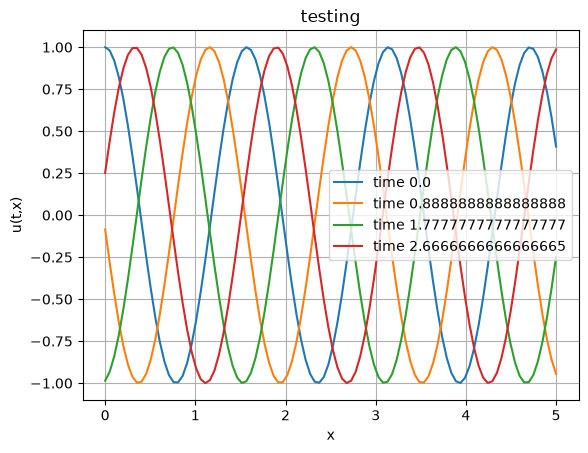

In [274]:
plt.plot(x_points, final_soln[:, 0], "-", label=f'time {sol.t[0]}')
plt.plot(x_points, final_soln[:, 1], "-", label=f'time {sol.t[1]}')
plt.plot(x_points, final_soln[:, 2], "-", label=f'time {sol.t[2]}')
plt.plot(x_points, final_soln[:, 3], "-", label=f'time {sol.t[3]}')

plt.xlabel("x")
plt.ylabel("u(t,x)")
plt.title("testing")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
sol.y.shape

(20, 10)

In [69]:
test = np.array([[1,2], [3,4]])
test

array([[1, 2],
       [3, 4]])

In [73]:
np.linalg.norm(test, axis=1)

array([2.23606798, 5.        ])

In [ ]:
np.linalg.norm(complex_sol, axis=0) # the momentum would be this squared * 2pi
# for travelling waves we expect it to say around 1

array([1.        , 0.99999994, 1.        , 0.99999994, 0.99999994,
       0.99999994, 1.        , 1.        , 0.99999994, 0.99999994],
      dtype=float32)

In [ ]:
squares = np.square(np.abs(complex_sol))
mass = np.einsum("at,a->t", squares, np.array([1,1/2,1/3,1/4,1/5,1/6,1/7,1/8,1/9,1/10]))

In [1]:
mass # would expect this to remain around 1/4

NameError: name 'mass' is not defined

In [41]:
# expierments
np.array(np.meshgrid(np.arange(10), np.arange(10))).shape

(2, 10, 10)

In [95]:
combos = np.array(np.meshgrid(np.arange(5), np.arange(5), np.arange(5))).flatten("F").reshape(125, 3)
# all indices are decreased by one. remember this when computing weight


In [96]:
combos

array([[0, 0, 0],
       [0, 1, 0],
       [0, 2, 0],
       [0, 3, 0],
       [0, 4, 0],
       [1, 0, 0],
       [1, 1, 0],
       [1, 2, 0],
       [1, 3, 0],
       [1, 4, 0],
       [2, 0, 0],
       [2, 1, 0],
       [2, 2, 0],
       [2, 3, 0],
       [2, 4, 0],
       [3, 0, 0],
       [3, 1, 0],
       [3, 2, 0],
       [3, 3, 0],
       [3, 4, 0],
       [4, 0, 0],
       [4, 1, 0],
       [4, 2, 0],
       [4, 3, 0],
       [4, 4, 0],
       [0, 0, 1],
       [0, 1, 1],
       [0, 2, 1],
       [0, 3, 1],
       [0, 4, 1],
       [1, 0, 1],
       [1, 1, 1],
       [1, 2, 1],
       [1, 3, 1],
       [1, 4, 1],
       [2, 0, 1],
       [2, 1, 1],
       [2, 2, 1],
       [2, 3, 1],
       [2, 4, 1],
       [3, 0, 1],
       [3, 1, 1],
       [3, 2, 1],
       [3, 3, 1],
       [3, 4, 1],
       [4, 0, 1],
       [4, 1, 1],
       [4, 2, 1],
       [4, 3, 1],
       [4, 4, 1],
       [0, 0, 2],
       [0, 1, 2],
       [0, 2, 2],
       [0, 3, 2],
       [0, 4, 2],
       [1,

In [97]:
test = np.array([-1, 1, 1])

In [202]:
m = np.sum(test * combos ,axis=1)
valid_m = np.expand_dims(m[(m < 5)*(m >= 0)], axis=1)
valid_combos = np.concatenate((combos[(m < 5)*(m >= 0)], valid_m), axis=1) # this will be all valid p,k,l,m
valid_combos[0]

array([0, 0, 0, 0])

In [ ]:
np.einsum("i,j,k->ijk", np.arange(5), np.arange(5), np.arange(5))[np.expand_dims(valid_combos[0][1:],axis=1)]

(3, 1, 5, 5)

In [ ]:
# example. this would give the indices for k,l,m if p = 0
test3 = np.delete(valid_combos[valid_combos[:, 0] == 0], 0, axis=1)

In [203]:
test4 = []
for p in range(5):
    array = np.delete(valid_combos[valid_combos[:, 0] == p], 0, axis=1)
    if array.size != 0:
        test4.append(array)

print(test4)
print(len(test4))

[array([[0, 0, 0],
       [1, 0, 1],
       [2, 0, 2],
       [3, 0, 3],
       [4, 0, 4],
       [0, 1, 1],
       [1, 1, 2],
       [2, 1, 3],
       [3, 1, 4],
       [0, 2, 2],
       [1, 2, 3],
       [2, 2, 4],
       [0, 3, 3],
       [1, 3, 4],
       [0, 4, 4]]), array([[1, 0, 0],
       [2, 0, 1],
       [3, 0, 2],
       [4, 0, 3],
       [0, 1, 0],
       [1, 1, 1],
       [2, 1, 2],
       [3, 1, 3],
       [4, 1, 4],
       [0, 2, 1],
       [1, 2, 2],
       [2, 2, 3],
       [3, 2, 4],
       [0, 3, 2],
       [1, 3, 3],
       [2, 3, 4],
       [0, 4, 3],
       [1, 4, 4]]), array([[2, 0, 0],
       [3, 0, 1],
       [4, 0, 2],
       [1, 1, 0],
       [2, 1, 1],
       [3, 1, 2],
       [4, 1, 3],
       [0, 2, 0],
       [1, 2, 1],
       [2, 2, 2],
       [3, 2, 3],
       [4, 2, 4],
       [0, 3, 1],
       [1, 3, 2],
       [2, 3, 3],
       [3, 3, 4],
       [0, 4, 2],
       [1, 4, 3],
       [2, 4, 4]]), array([[3, 0, 0],
       [4, 0, 1],
       [2, 1, 0],
   

In [193]:
print(np.einsum("i,j,k->ijk", np.arange(10), np.arange(10), np.arange(10)))

[[[  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]
  [  0   0   0   0   0   0   0   0   0   0]]

 [[  0   0   0   0   0   0   0   0   0   0]
  [  0   1   2   3   4   5   6   7   8   9]
  [  0   2   4   6   8  10  12  14  16  18]
  [  0   3   6   9  12  15  18  21  24  27]
  [  0   4   8  12  16  20  24  28  32  36]
  [  0   5  10  15  20  25  30  35  40  45]
  [  0   6  12  18  24  30  36  42  48  54]
  [  0   7  14  21  28  35  42  49  56  63]
  [  0   8  16  24  32  40  48  56  64  72]
  [  0   9  18  27  36  45  54  63  72  81]]

 [[  0   0   0   0   0   0   0   0   0   0]
  [  0   2   4   6   8  10  12  14  16  18]
  [  0   4   8  12  16  20  

In [ ]:
sigma = 0
combos2 = np.meshgrid(np.arange(5), np.arange(5), np.arange(5), np.arange(5)) # again +1 because of how indices change
weights = (0+1j) * (combos2[0]+1) * (np.minimum.reduce([combos2[0]+1, combos2[1]+1, combos2[2]+1, combos2[3]+1]) - sigma)
# might be able to just add 1 outside the minimum rather than in each thing
# i think now the indices on weights are p,k,l,m but we can check with travelling waves in the simulation
# need to set weights at invalid indices to 0, but i've computed the valid indices! so probably change it to find invalid indices, then we set weights to 0
# at the invalid indices, then we compute the following which is what will be returned by Csigma.
# np.einsum("pklm,k,l,m->p", weights, a, a, a.conj)
m = combos2[1] + combos2[2] - combos2[0]
illegal_m = (m > 4) + (m < 0) + (combos2[3] != m) # 4 here is N-1 in the original maths way

weights[illegal_m] = 0
print(weights)
# if everything is correct, this should be the weights array we want

#valid_combos
#i(p+1) min (p+1,k+1,l+1,m+1)
# adding 1 because CS index notation means indices are one under what they should be

[[[[False  True  True  True  True]
   [ True False  True  True  True]
   [ True  True False  True  True]
   [ True  True  True False  True]
   [ True  True  True  True False]]

  [[ True  True  True  True  True]
   [False  True  True  True  True]
   [ True False  True  True  True]
   [ True  True False  True  True]
   [ True  True  True False  True]]

  [[ True  True  True  True  True]
   [ True  True  True  True  True]
   [False  True  True  True  True]
   [ True False  True  True  True]
   [ True  True False  True  True]]

  [[ True  True  True  True  True]
   [ True  True  True  True  True]
   [ True  True  True  True  True]
   [False  True  True  True  True]
   [ True False  True  True  True]]

  [[ True  True  True  True  True]
   [ True  True  True  True  True]
   [ True  True  True  True  True]
   [ True  True  True  True  True]
   [False  True  True  True  True]]]


 [[[ True False  True  True  True]
   [ True  True False  True  True]
   [ True  True  True False  True]
   [ Tru

array([[[[0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0]],

        [[1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1]],

        [[2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2]],

        [[3, 3, 3, 3, 3],
         [3, 3, 3, 3, 3],
         [3, 3, 3, 3, 3],
         [3, 3, 3, 3, 3],
         [3, 3, 3, 3, 3]],

        [[4, 4, 4, 4, 4],
         [4, 4, 4, 4, 4],
         [4, 4, 4, 4, 4],
         [4, 4, 4, 4, 4],
         [4, 4, 4, 4, 4]]],


       [[[0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0]],

        [[1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1],
         [1, 1, 1, 1, 1]],

        [[2, 2, 2, 2, 2],
         [2, 2, 2, 2, 2],
         [2, 2, 2, 2, 

In [ ]:
# extracting the value of the derivative. need to add in weights, and multiply by ip in the append expresssion.
result = []
for p in range(5):
    print(np.einsum("i,j,k->ijk", np.arange(5), np.arange(5), np.arange(5))[test4[p][:, 0], test4[p][:, 1], test4[p][:, 2]])
    print(len(np.einsum("i,j,k->ijk", np.arange(5), np.arange(5), np.arange(5))[test4[p][:, 0], test4[p][:, 1], test4[p][:, 2]]))
    result.append(np.sum(np.einsum("i,j,k->ijk", np.arange(5), np.arange(5), np.arange(5))[test4[p][:, 0], test4[p][:, 1], test4[p][:, 2]]))
result = np.array(result)


[ 0  0  0  0  0  0  2  6 12  0  6 16  0 12  0]
15
[ 0  0  0  0  0  1  4  9 16  0  4 12 24  0  9 24  0 16]
18
[ 0  0  0  0  2  6 12  0  2  8 18 32  0  6 18 36  0 12 32]
19
[ 0  0  0  3  8  0  4 12 24  0  3 12 27 48  0  8 24 48]
18
[ 0  0  4  0  6 16  0  6 18 36  0  4 16 36 64]
15
[ 54 119 184 221 206]
[[0 0 0]
 [1 0 1]
 [2 0 2]
 [3 0 3]
 [4 0 4]
 [0 1 1]
 [1 1 2]
 [2 1 3]
 [3 1 4]
 [0 2 2]
 [1 2 3]
 [2 2 4]
 [0 3 3]
 [1 3 4]
 [0 4 4]]
[0 1 2 3 4 0 1 2 3 0 1 2 0 1 0] [0 0 0 0 0 1 1 1 1 2 2 2 3 3 4] [0 1 2 3 4 1 2 3 4 2 3 4 3 4 4]
[2]


In [160]:
np.einsum("i,j,k->ijk", np.arange(5), np.arange(5), np.arange(5))[tuple(test2)]

array([0])

In [157]:
np.einsum("i,j,k->ijk", np.arange(5), np.arange(5), np.arange(5))[valid_combos[2][1:]].shape

(3, 5, 5)